First 5 rows of features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


First 5 target values:


,disease_progression
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0



Missing values in dataset:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Feature statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


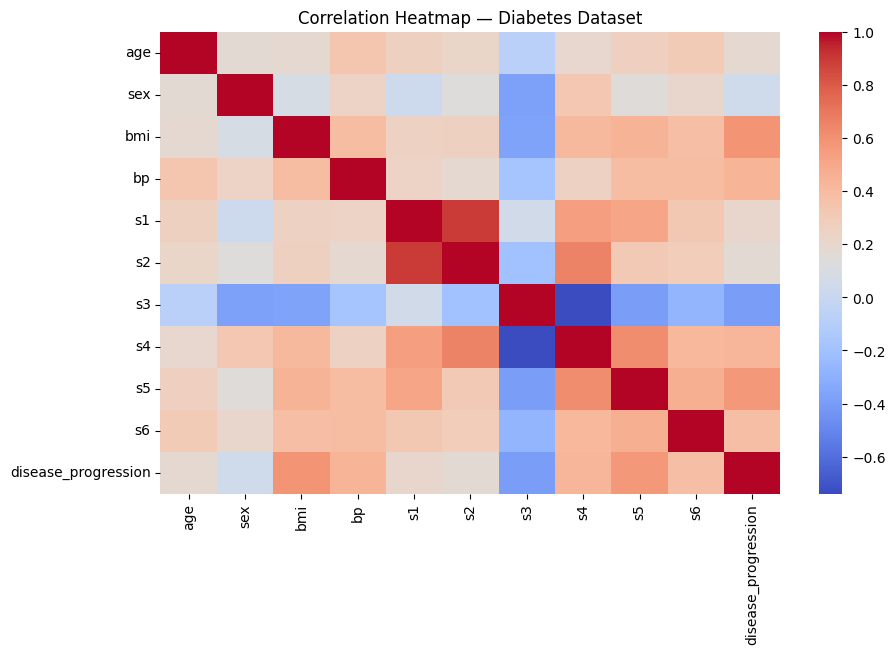


Model Performance Comparison:


,MSE,RMSE,MAE,R²
Linear Regression,2900.193628,53.853446,42.794095,0.452603
Ridge Regression,2892.014566,53.777454,42.811999,0.454147
Lasso Regression,2898.368019,53.836493,42.795018,0.452947
Decision Tree,4887.000000,69.907081,53.921348,0.077603
Random Forest,2959.180562,54.398351,44.171236,0.441469


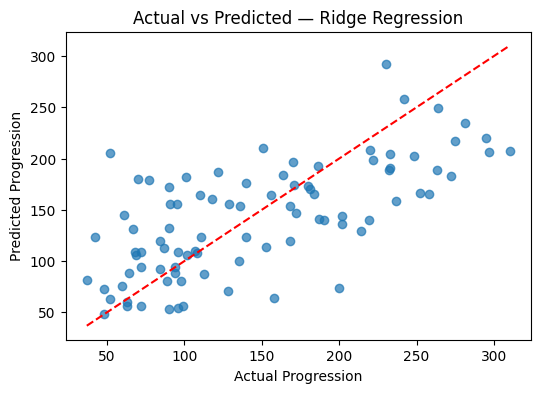


Best Ridge Alpha: {'alpha': 50}


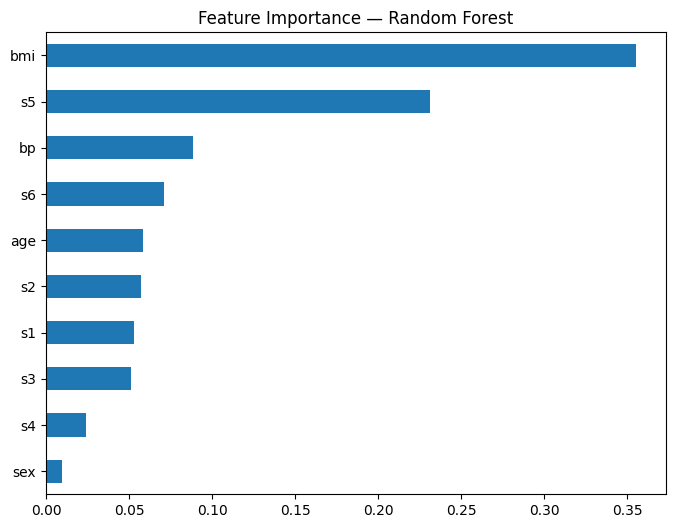

In [1]:
# ============================================================
# MACHINE LEARNING PROJECT — DIABETES DATASET (REGRESSION)
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# 2. LOAD THE DIABETES DATASET
# ------------------------------------------------------------

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="disease_progression")

print("First 5 rows of features:")
display(X.head())

print("First 5 target values:")
display(y.head())

# ------------------------------------------------------------
# 3. TRAIN–TEST SPLIT (80/20)
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------

print("\nMissing values in dataset:")
print(X.isna().sum())

print("\nFeature statistics:")
display(X.describe())

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(X.join(y).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap — Diabetes Dataset")
plt.show()

# Pairplot (optional)
# sns.pairplot(X.join(y))
# plt.show()

# ------------------------------------------------------------
# 5. DATA SCALING
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 6. MODEL TRAINING — MULTIPLE MODELS
# ------------------------------------------------------------

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = [mse, rmse, mae, r2]

# ------------------------------------------------------------
# 7. DISPLAY MODEL PERFORMANCE
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results,
    index=["MSE", "RMSE", "MAE", "R²"]
).T

print("\nModel Performance Comparison:")
display(results_df)

# ------------------------------------------------------------
# 8. VISUALIZE ACTUAL vs PREDICTED (BEST MODEL)
# ------------------------------------------------------------

best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_best, alpha=0.7)
plt.xlabel("Actual Progression")
plt.ylabel("Predicted Progression")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.show()

# ------------------------------------------------------------
# 9. HYPERPARAMETER TUNING (Ridge Example)
# ------------------------------------------------------------

ridge_params = {"alpha": [0.1, 1, 10, 50, 100]}

ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5)
ridge_grid.fit(X_train_scaled, y_train)

print("\nBest Ridge Alpha:", ridge_grid.best_params_)

# ------------------------------------------------------------
# 10. FEATURE IMPORTANCE (Random Forest)
# ------------------------------------------------------------

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Feature Importance — Random Forest")
plt.show()